# Clinical GraphRAG Pro — Retrieval Pipeline Deep Dive
### An interactive walkthrough of hybrid retrieval, RRF fusion, and clinical context assembly

This notebook explains the retrieval pipeline as implemented in the repository. 
Where live backend state is unavailable, we use synthetic fallbacks so the notebook remains runnable offline.

In [1]:
# This notebook requires the backend dependencies
# Run from repo root: pip install -r backend/requirements.txt
import os
import sys
import time
from pathlib import Path

os.environ.setdefault('DEBUG', 'true')
os.environ.setdefault('JWT_SECRET', 'notebook_debug_secret_value_1234567890')
os.environ.setdefault('CORS_ORIGINS', '["http://localhost:3000"]')
os.environ.setdefault('TOKENIZERS_PARALLELISM', 'false')

sys.path.insert(0, '../backend')

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

np.random.seed(42)
print('Python executable:', sys.executable)
print('Notebook directory:', Path('.').resolve())
print('Setup complete.')

Python executable: backend/.venv/bin/python
Notebook directory: notebooks
Setup complete.


## Section 1: Document Chunking

### Load A Sample Clinical Document

In [2]:
sample_text = (
    "PATIENT: John D., 58M\n"
    "CHIEF COMPLAINT: Progressive fatigue and exertional dyspnea\n\n"
    "HISTORY OF PRESENT ILLNESS:\n"
    "John D. is a 58-year-old man with hypertension, type 2 diabetes mellitus, and hyperlipidemia who presents with three months of gradually worsening fatigue and shortness of breath while climbing one flight of stairs. "
    "He reports a marked decline in exercise tolerance and intermittent ankle swelling near the end of the day. "
    "He denies syncope, pleuritic chest pain, fever, or productive cough. "
    "Over the prior two weeks he has noticed orthopnea requiring two pillows and occasional paroxysmal nocturnal dyspnea. "
    "He also describes reduced appetite and early satiety but no frank abdominal pain.\n\n"
    "PAST MEDICAL HISTORY:\n"
    "Hypertension diagnosed in 2016, type 2 diabetes diagnosed in 2014, hyperlipidemia, and obesity. "
    "No prior myocardial infarction or known valvular disease.\n\n"
    "MEDICATIONS ON PRESENTATION:\n"
    "Metformin 1000 mg twice daily, lisinopril 20 mg daily, atorvastatin 40 mg nightly, and hydrochlorothiazide 25 mg daily. "
    "He admits missing several evening doses over the last month due to shift work.\n\n"
    "PHYSICAL EXAM:\n"
    "Blood pressure 154/92 mmHg, heart rate 102 bpm, respiratory rate 20/min, oxygen saturation 95% on room air, temperature 36.8 C. "
    "Elevated jugular venous pressure to 10 cm. Bibasilar crackles and trace bilateral pitting edema. "
    "Cardiac exam reveals regular tachycardia with an S3 gallop.\n\n"
    "LABORATORY DATA:\n"
    "BNP 780 pg/mL, creatinine 1.3 mg/dL (baseline 1.0), sodium 133 mmol/L, potassium 4.7 mmol/L, HbA1c 8.4%. "
    "Troponin I negative x2.\n\n"
    "IMAGING AND STUDIES:\n"
    "Chest radiograph shows mild pulmonary vascular congestion without focal consolidation. "
    "ECG demonstrates sinus tachycardia with left ventricular hypertrophy criteria. "
    "Transthoracic echocardiogram reveals mildly reduced left ventricular ejection fraction at 45%, grade II diastolic dysfunction, and mild left atrial enlargement.\n\n"
    "ASSESSMENT AND PLAN:\n"
    "New decompensated heart failure with mildly reduced EF, likely on a background of long-standing hypertensive heart disease and suboptimal cardiometabolic control. "
    "Begin IV loop diuresis, optimize guideline-directed medical therapy, monitor daily weights and strict intake/output, and provide sodium-restriction counseling. "
    "Continue ACE inhibitor if renal function remains stable; consider beta-blocker initiation after euvolemia is achieved. "
    "Arrange cardiology follow-up within one week of discharge and reinforce diabetes management with outpatient endocrinology referral."
)

print('Sample note word count:', len(sample_text.split()))
print(sample_text[:350] + ' ...')

Sample note word count: 347
PATIENT: John D., 58M
CHIEF COMPLAINT: Progressive fatigue and exertional dyspnea

HISTORY OF PRESENT ILLNESS:
John D. is a 58-year-old man with hypertension, type 2 diabetes mellitus, and hyperlipidemia who presents with three months of gradually worsening fatigue and shortness of breath while climbing one flight of stairs. He reports a marked dec ...


### Naive Chunking (What Not To Do)

In [3]:
def naive_fixed_chunks(text: str, char_window: int = 260):
    return [text[i:i+char_window] for i in range(0, len(text), char_window)]

naive_chunks = naive_fixed_chunks(sample_text, char_window=260)
print('Naive chunks:', len(naive_chunks))

for idx, chunk in enumerate(naive_chunks[:4], start=1):
    tail = chunk[-40:].replace('\n', ' ')
    head_next = naive_chunks[idx][:40].replace('\n', ' ') if idx < len(naive_chunks) else ''
    print(f"\n--- Naive chunk {idx} ---")
    print(chunk.replace('\n', ' ')[:220] + '...')
    if head_next:
        print(f"Break artifact -> '{tail}' || '{head_next}'")

Naive chunks: 10

--- Naive chunk 1 ---
PATIENT: John D., 58M CHIEF COMPLAINT: Progressive fatigue and exertional dyspnea  HISTORY OF PRESENT ILLNESS: John D. is a 58-year-old man with hypertension, type 2 diabetes mellitus, and hyperlipidemia who presents wit...
Break artifact -> 'h three months of gradually worsening fa' || 'tigue and shortness of breath while clim'

--- Naive chunk 2 ---
tigue and shortness of breath while climbing one flight of stairs. He reports a marked decline in exercise tolerance and intermittent ankle swelling near the end of the day. He denies syncope, pleuritic chest pain, fever...
Break artifact -> ', or productive cough. Over the prior tw' || 'o weeks he has noticed orthopnea requiri'

--- Naive chunk 3 ---
o weeks he has noticed orthopnea requiring two pillows and occasional paroxysmal nocturnal dyspnea. He also describes reduced appetite and early satiety but no frank abdominal pain.  PAST MEDICAL HISTORY: Hypertension di...
Break artifact -> 'agnosed i

### The Actual Chunking Implementation

In [4]:
from app.services.vector_store import vector_store_service

start = time.perf_counter()
actual_chunks = vector_store_service.chunk_text(sample_text, chunk_size=110, overlap=22)
chunk_time_ms = (time.perf_counter() - start) * 1000

chunk_texts = [c.get('text') or c.get('chunk_text', '') for c in actual_chunks]
chunk_lengths = [len(t.split()) for t in chunk_texts]

def suffix_prefix_overlap_words(left: str, right: str, max_overlap: int = 50):
    lw = left.split()
    rw = right.split()
    best = 0
    for k in range(1, min(max_overlap, len(lw), len(rw)) + 1):
        if lw[-k:] == rw[:k]:
            best = k
    return best

overlap_sizes = [
    suffix_prefix_overlap_words(chunk_texts[i], chunk_texts[i + 1], max_overlap=40)
    for i in range(len(chunk_texts) - 1)
] if len(chunk_texts) > 1 else []

print(f'Actual chunking runtime: {chunk_time_ms:.2f} ms')
print('Chunk count:', len(chunk_texts))
print(f'Mean chunk size: {np.mean(chunk_lengths):.2f} words')
print(f'Mean measured overlap: {np.mean(overlap_sizes) if overlap_sizes else 0:.2f} words')

for idx, text in enumerate(chunk_texts[:3], start=1):
    print(f"\n--- Actual chunk {idx} ({len(text.split())} words) ---")
    print(text[:280] + ('...' if len(text) > 280 else ''))

Actual chunking runtime: 0.76 ms
Chunk count: 4
Mean chunk size: 98.50 words
Mean measured overlap: 15.67 words

--- Actual chunk 1 (106 words) ---
PATIENT: John D., 58M CHIEF COMPLAINT: Progressive fatigue and exertional dyspnea HISTORY OF PRESENT ILLNESS: John D. is a 58-year-old man with hypertension, type 2 diabetes mellitus, and hyperlipidemia who presents with three months of gradually worsening fatigue and shortness o...

--- Actual chunk 2 (108 words) ---
He also describes reduced appetite and early satiety but no frank abdominal pain. PAST MEDICAL HISTORY: Hypertension diagnosed in 2016, type 2 diabetes diagnosed in 2014, hyperlipidemia, and obesity. No prior myocardial infarction or known valvular disease. MEDICATIONS ON PRESENT...

--- Actual chunk 3 (87 words) ---
Elevated jugular venous pressure to 10 cm. Bibasilar crackles and trace bilateral pitting edema. Cardiac exam reveals regular tachycardia with an S3 gallop. LABORATORY DATA: BNP 780 pg/mL, creatinine 1.3 mg/dL (ba

### Visualization

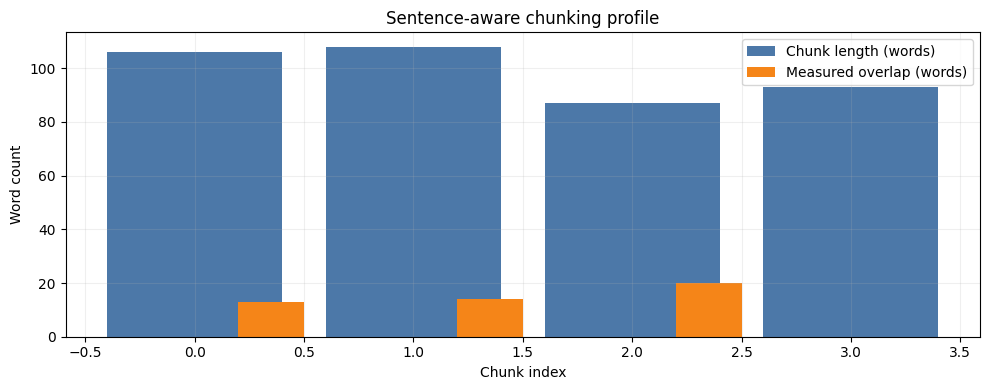

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(chunk_lengths))
ax.bar(x, chunk_lengths, label='Chunk length (words)', color='#4c78a8')

if overlap_sizes:
    overlap_x = np.arange(len(overlap_sizes)) + 0.35
    ax.bar(overlap_x, overlap_sizes, width=0.3, label='Measured overlap (words)', color='#f58518')

ax.set_title('Sentence-aware chunking profile')
ax.set_xlabel('Chunk index')
ax.set_ylabel('Word count')
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Section 2: Embedding

### What Embedding Looks Like

In [6]:
from sentence_transformers import SentenceTransformer

start = time.perf_counter()
if 'EMBED_MODEL' not in globals():
    EMBED_MODEL = SentenceTransformer('sentence-transformers/all-mpnet-base-v2')
load_ms = (time.perf_counter() - start) * 1000

sentences = [
    'Lisinopril is an ACE inhibitor used for hypertension',
    'The patient has high blood pressure treated with an ACE inhibitor',
    'The restaurant serves Italian food',
]
embs = EMBED_MODEL.encode(sentences, normalize_embeddings=True)

sim12 = float(np.dot(embs[0], embs[1]))
sim13 = float(np.dot(embs[0], embs[2]))

print(f'Embedding model ready in {load_ms:.2f} ms (0 ms if cached).')
print(f'Sentence 1 vs 2 cosine similarity: {sim12:.4f}')
print(f'Sentence 1 vs 3 cosine similarity: {sim13:.4f}')

backend/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Embedding model ready in 8447.69 ms (0 ms if cached).
Sentence 1 vs 2 cosine similarity: 0.6609
Sentence 1 vs 3 cosine similarity: 0.1052


### Visualization: Embedding Space

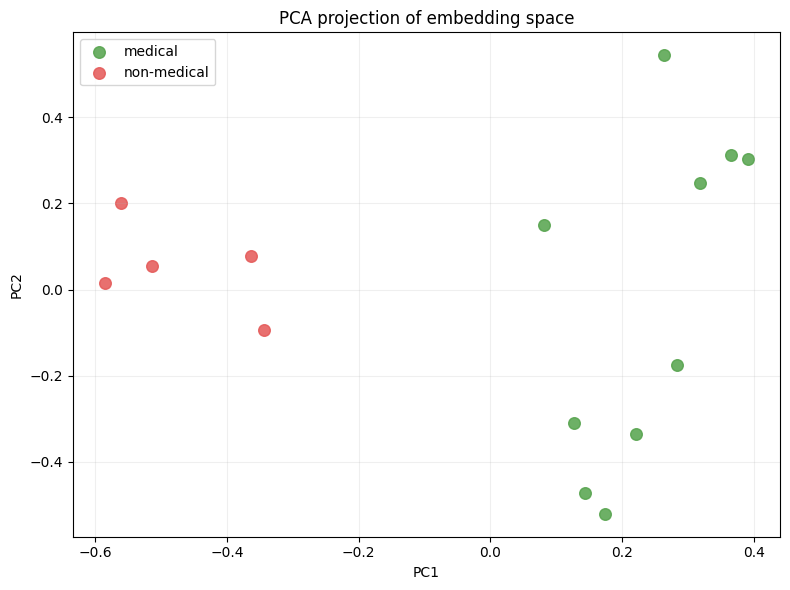

Embedding + PCA runtime: 519.15 ms


In [7]:
medical_sentences = [
    'Chest pain radiating to the left arm suggests myocardial ischemia',
    'Elevated troponin supports acute coronary syndrome',
    'Metformin is first-line therapy for type 2 diabetes',
    'HbA1c remained above target despite lifestyle counseling',
    'Creatinine rose after contrast exposure',
    'Lisinopril can improve blood pressure and proteinuria',
    'Wheezing improved after albuterol nebulization',
    'BNP elevation may indicate decompensated heart failure',
    'Atrial fibrillation increases embolic stroke risk',
    'Warfarin requires INR monitoring during antibiotic therapy',
]
non_medical_sentences = [
    'The concert started late because of heavy traffic',
    'Italian food is popular in the downtown district',
    'The football match ended in a draw',
    'She bought a new camera for travel photography',
    'Mountain weather changed quickly after sunrise',
]
all_sentences = medical_sentences + non_medical_sentences
labels = ['medical'] * len(medical_sentences) + ['non-medical'] * len(non_medical_sentences)

start = time.perf_counter()
all_emb = EMBED_MODEL.encode(all_sentences, normalize_embeddings=True)
points = PCA(n_components=2, random_state=42).fit_transform(all_emb)
elapsed = (time.perf_counter() - start) * 1000

fig, ax = plt.subplots(figsize=(8, 6))
for label, color in [('medical', '#54a24b'), ('non-medical', '#e45756')]:
    idx = [i for i, l in enumerate(labels) if l == label]
    ax.scatter(points[idx, 0], points[idx, 1], label=label, color=color, s=70, alpha=0.85)

ax.set_title('PCA projection of embedding space')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()
print(f'Embedding + PCA runtime: {elapsed:.2f} ms')

### Why This Model Has Medical Abbreviation Limits

In [8]:
amb = [
    'MI',
    'myocardial infarction',
    'Michigan',
    'The patient suffered an MI last year',
    'She moved to MI for graduate school',
]
start = time.perf_counter()
amb_emb = EMBED_MODEL.encode(amb, normalize_embeddings=True)
elapsed = (time.perf_counter() - start) * 1000

sim_clinical = float(np.dot(amb_emb[0], amb_emb[1]))
sim_geo = float(np.dot(amb_emb[0], amb_emb[2]))

print(f'Embedding runtime: {elapsed:.2f} ms')
print(f"cos('MI', 'myocardial infarction') = {sim_clinical:.4f}")
print(f"cos('MI', 'Michigan') = {sim_geo:.4f}")
print('This ambiguity motivates adding BM25 exact-token retrieval.')

Embedding runtime: 115.93 ms
cos('MI', 'myocardial infarction') = 0.1938
cos('MI', 'Michigan') = 0.8066
This ambiguity motivates adding BM25 exact-token retrieval.


## Section 3: FAISS Index

### Build A Small FAISS Index From Scratch

In [9]:
import faiss

condition_terms = ['heart failure', 'hypertension', 'diabetes', 'CKD', 'atrial fibrillation']
med_terms = ['lisinopril', 'metformin', 'furosemide', 'apixaban', 'atorvastatin']
context_terms = ['renal dysfunction', 'fluid overload', 'electrolyte monitoring', 'dose adjustment', 'outpatient follow-up']

corpus_chunks = []
for i in range(100):
    cond = np.random.choice(condition_terms)
    med = np.random.choice(med_terms)
    ctx = np.random.choice(context_terms)
    corpus_chunks.append(
        f'Chunk {i:03d}: Patient with {cond}. Current therapy includes {med}. Clinical focus: {ctx}. Consider comorbidity-aware management.'
    )
corpus_ids = [f'chunk_{i:03d}' for i in range(len(corpus_chunks))]

start = time.perf_counter()
chunk_embeddings = EMBED_MODEL.encode(corpus_chunks, normalize_embeddings=True)
embed_ms = (time.perf_counter() - start) * 1000

faiss_index = faiss.IndexFlatL2(chunk_embeddings.shape[1])
start2 = time.perf_counter()
faiss_index.add(np.asarray(chunk_embeddings, dtype='float32'))
index_ms = (time.perf_counter() - start2) * 1000

index_size_bytes = faiss_index.ntotal * faiss_index.d * 4
print(f'Embedding runtime: {embed_ms:.2f} ms')
print(f'Index build runtime: {index_ms:.2f} ms')
print('Index vectors:', faiss_index.ntotal)
print('Embedding dimension:', faiss_index.d)
print(f'Approx index memory: {index_size_bytes/1024:.2f} KB')

Embedding runtime: 6025.47 ms
Index build runtime: 0.35 ms
Index vectors: 100
Embedding dimension: 768
Approx index memory: 300.00 KB


### Query The Index

In [10]:
query = 'ACE inhibitor dosing in renal failure'
start = time.perf_counter()
q_emb = EMBED_MODEL.encode([query], normalize_embeddings=True)
D, I = faiss_index.search(np.asarray(q_emb, dtype='float32'), 5)
faiss_query_ms = (time.perf_counter() - start) * 1000

faiss_top_indices = I[0].tolist()
faiss_top_distances = D[0].tolist()
faiss_top_ids = [corpus_ids[idx] for idx in faiss_top_indices]

print(f'FAISS query runtime: {faiss_query_ms:.2f} ms')
for rank, (idx, dist) in enumerate(zip(faiss_top_indices, faiss_top_distances), start=1):
    print(f"\\nRank {rank} | {corpus_ids[idx]} | L2 distance={dist:.4f}")
    print(corpus_chunks[idx])

FAISS query runtime: 88.42 ms
\nRank 1 | chunk_013 | L2 distance=0.8254
Chunk 013: Patient with hypertension. Current therapy includes apixaban. Clinical focus: renal dysfunction. Consider comorbidity-aware management.
\nRank 2 | chunk_094 | L2 distance=0.8529
Chunk 094: Patient with heart failure. Current therapy includes apixaban. Clinical focus: renal dysfunction. Consider comorbidity-aware management.
\nRank 3 | chunk_056 | L2 distance=0.8588
Chunk 056: Patient with heart failure. Current therapy includes apixaban. Clinical focus: renal dysfunction. Consider comorbidity-aware management.
\nRank 4 | chunk_059 | L2 distance=0.8615
Chunk 059: Patient with heart failure. Current therapy includes atorvastatin. Clinical focus: renal dysfunction. Consider comorbidity-aware management.
\nRank 5 | chunk_033 | L2 distance=0.8732
Chunk 033: Patient with heart failure. Current therapy includes apixaban. Clinical focus: renal dysfunction. Consider comorbidity-aware management.


### Visualization: Distance Distribution

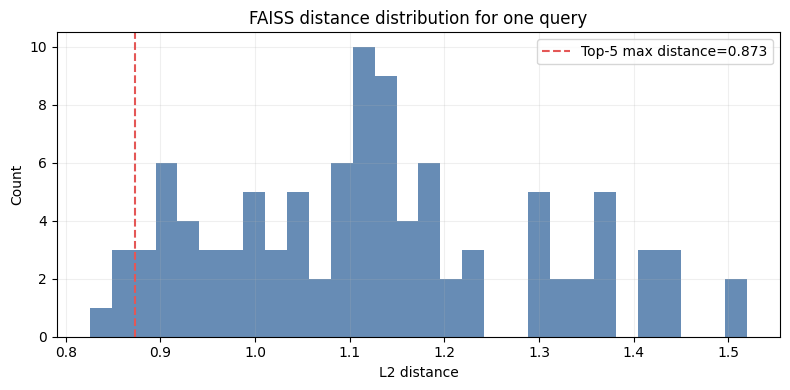

Full distance scan runtime: 0.96 ms
Hard distance thresholds are query-dependent.


In [11]:
start = time.perf_counter()
D_all, I_all = faiss_index.search(np.asarray(q_emb, dtype='float32'), faiss_index.ntotal)
full_scan_ms = (time.perf_counter() - start) * 1000

all_distances = D_all[0]
tentative_cutoff = max(faiss_top_distances)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(all_distances, bins=30, color='#4c78a8', alpha=0.85)
ax.axvline(tentative_cutoff, color='#e45756', linestyle='--', label=f'Top-5 max distance={tentative_cutoff:.3f}')
ax.set_title('FAISS distance distribution for one query')
ax.set_xlabel('L2 distance')
ax.set_ylabel('Count')
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print(f'Full distance scan runtime: {full_scan_ms:.2f} ms')
print('Hard distance thresholds are query-dependent.')

## Section 4: BM25 Index

### BM25 Intuition

In [12]:
from rank_bm25 import BM25Okapi
import re

def tokenize(text: str):
    return re.findall(r"\b[\w-]+\b", text.lower())

tiny_docs = [
    'lisinopril dose adjustment required in renal failure',
    'patient education for low sodium diet and exercise',
    'renal failure follow-up with ACE inhibitor monitoring',
]
small_query = 'ACE inhibitor renal failure dosing'
bm25_tiny = BM25Okapi([tokenize(d) for d in tiny_docs])
small_scores = bm25_tiny.get_scores(tokenize(small_query))

print('BM25 scores on toy corpus:')
for d, s in zip(tiny_docs, small_scores):
    print(f'  {s:6.3f} | {d}')

BM25 scores on toy corpus:
   0.209 | lisinopril dose adjustment required in renal failure
   0.000 | patient education for low sodium diet and exercise
   1.252 | renal failure follow-up with ACE inhibitor monitoring


### Run BM25 Search On The Same Query

In [13]:
tokenized_corpus = [tokenize(c) for c in corpus_chunks]
bm25 = BM25Okapi(tokenized_corpus)

start = time.perf_counter()
bm25_scores = bm25.get_scores(tokenize(query))
bm25_query_ms = (time.perf_counter() - start) * 1000

bm25_top_indices = np.argsort(bm25_scores)[::-1][:5].tolist()
bm25_top_ids = [corpus_ids[i] for i in bm25_top_indices]

print(f'BM25 query runtime: {bm25_query_ms:.2f} ms')
for rank, idx in enumerate(bm25_top_indices, start=1):
    print(f"\\nRank {rank} | {corpus_ids[idx]} | BM25 score={bm25_scores[idx]:.4f}")
    print(corpus_chunks[idx])

BM25 query runtime: 0.50 ms
\nRank 1 | chunk_050 | BM25 score=2.1461
Chunk 050: Patient with heart failure. Current therapy includes lisinopril. Clinical focus: renal dysfunction. Consider comorbidity-aware management.
\nRank 2 | chunk_051 | BM25 score=2.1461
Chunk 051: Patient with heart failure. Current therapy includes furosemide. Clinical focus: renal dysfunction. Consider comorbidity-aware management.
\nRank 3 | chunk_028 | BM25 score=2.1461
Chunk 028: Patient with heart failure. Current therapy includes lisinopril. Clinical focus: renal dysfunction. Consider comorbidity-aware management.
\nRank 4 | chunk_078 | BM25 score=2.1461
Chunk 078: Patient with heart failure. Current therapy includes metformin. Clinical focus: renal dysfunction. Consider comorbidity-aware management.
\nRank 5 | chunk_060 | BM25 score=2.1461
Chunk 060: Patient with heart failure. Current therapy includes furosemide. Clinical focus: renal dysfunction. Consider comorbidity-aware management.


### Side-By-Side Comparison Table

In [14]:
from IPython.display import Markdown, display

faiss_rank_map = {doc: i + 1 for i, doc in enumerate(faiss_top_ids)}
bm25_rank_map = {doc: i + 1 for i, doc in enumerate(bm25_top_ids)}

faiss_score_map = {corpus_ids[idx]: float(1.0 / (1.0 + dist)) for idx, dist in zip(faiss_top_indices, faiss_top_distances)}
bm25_score_map = {corpus_ids[idx]: float(bm25_scores[idx]) for idx in bm25_top_indices}

union_docs = list(dict.fromkeys(faiss_top_ids + bm25_top_ids))
rows = [
    '| Chunk | FAISS rank | FAISS score | BM25 rank | BM25 score |',
    '|---|---:|---:|---:|---:|',
]
for doc in union_docs:
    rows.append(
        f"| {doc} | {faiss_rank_map.get(doc, '-')} | {faiss_score_map.get(doc, float('nan')):.4f} | {bm25_rank_map.get(doc, '-')} | {bm25_score_map.get(doc, float('nan')):.4f} |"
    )

display(Markdown('\n'.join(rows)))
disagreement = [d for d in union_docs if d in faiss_rank_map and d in bm25_rank_map and faiss_rank_map[d] != bm25_rank_map[d]]
print('Rank disagreements:', disagreement if disagreement else 'None in top-5 union')

| Chunk | FAISS rank | FAISS score | BM25 rank | BM25 score |
|---|---:|---:|---:|---:|
| chunk_013 | 1 | 0.5478 | - | nan |
| chunk_094 | 2 | 0.5397 | - | nan |
| chunk_056 | 3 | 0.5380 | - | nan |
| chunk_059 | 4 | 0.5372 | - | nan |
| chunk_033 | 5 | 0.5339 | - | nan |
| chunk_050 | - | nan | 1 | 2.1461 |
| chunk_051 | - | nan | 2 | 2.1461 |
| chunk_028 | - | nan | 3 | 2.1461 |
| chunk_078 | - | nan | 4 | 2.1461 |
| chunk_060 | - | nan | 5 | 2.1461 |

Rank disagreements: None in top-5 union


## Section 5: RRF Fusion

### The Problem With Naive Score Averaging

In [15]:
paired_docs = list(dict.fromkeys(faiss_top_ids + bm25_top_ids))
print('Doc ID | FAISS(sim) | BM25(raw) | Naive average')
for doc in paired_docs:
    faiss_sim = faiss_score_map.get(doc, 0.0)
    bm25_raw = bm25_score_map.get(doc, 0.0)
    naive_avg = 0.5 * (faiss_sim + bm25_raw)
    print(f'{doc} | {faiss_sim:.4f} | {bm25_raw:.4f} | {naive_avg:.4f}')
print('\nNaive averaging is dominated by BM25 score scale.')

Doc ID | FAISS(sim) | BM25(raw) | Naive average
chunk_013 | 0.5478 | 0.0000 | 0.2739
chunk_094 | 0.5397 | 0.0000 | 0.2699
chunk_056 | 0.5380 | 0.0000 | 0.2690
chunk_059 | 0.5372 | 0.0000 | 0.2686
chunk_033 | 0.5339 | 0.0000 | 0.2669
chunk_050 | 0.0000 | 2.1461 | 1.0730
chunk_051 | 0.0000 | 2.1461 | 1.0730
chunk_028 | 0.0000 | 2.1461 | 1.0730
chunk_078 | 0.0000 | 2.1461 | 1.0730
chunk_060 | 0.0000 | 2.1461 | 1.0730

Naive averaging is dominated by BM25 score scale.


### Implement RRF From Scratch

In [16]:
def reciprocal_rank_fusion(rankings: list[list[str]], k: int = 60) -> dict:
    """
    rankings: list of ranked document ID lists
    k: constant to prevent top-ranked documents from dominating
    Returns: document_id -> RRF score
    """
    scores = {}
    for ranking in rankings:
        for rank, doc_id in enumerate(ranking, start=1):
            scores[doc_id] = scores.get(doc_id, 0) + 1 / (k + rank)
    return dict(sorted(scores.items(), key=lambda x: x[1], reverse=True))

start = time.perf_counter()
faiss_ranked_20 = [corpus_ids[i] for i in I_all[0][:20]]
bm25_ranked_20 = [corpus_ids[i] for i in np.argsort(bm25_scores)[::-1][:20]]
rrf_scores = reciprocal_rank_fusion([faiss_ranked_20, bm25_ranked_20], k=60)
rrf_ms = (time.perf_counter() - start) * 1000

print(f'RRF runtime: {rrf_ms:.4f} ms')
for i, (doc, score) in enumerate(list(rrf_scores.items())[:10], start=1):
    print(f'  {i:2d}. {doc} -> {score:.6f}')

RRF runtime: 0.3132 ms
   1. chunk_059 -> 0.030777
   2. chunk_050 -> 0.030679
   3. chunk_094 -> 0.030622
   4. chunk_028 -> 0.030579
   5. chunk_056 -> 0.030159
   6. chunk_033 -> 0.030090
   7. chunk_078 -> 0.029514
   8. chunk_051 -> 0.029462
   9. chunk_060 -> 0.028898
  10. chunk_073 -> 0.028624


### Visualization: Before And After RRF

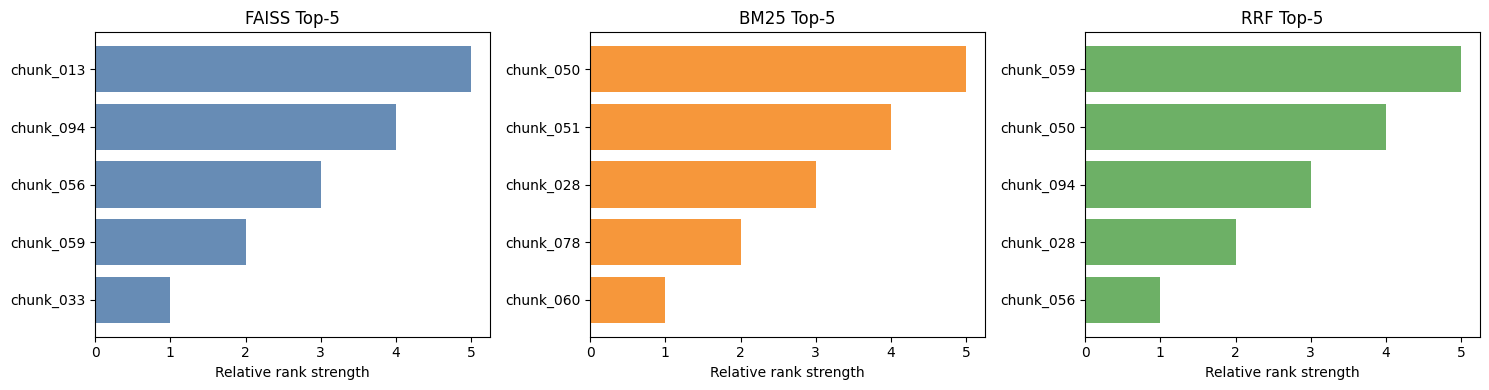

RRF docs rescued from lower ranks in both systems: None in this run


In [17]:
top5_faiss = faiss_ranked_20[:5]
top5_bm25 = bm25_ranked_20[:5]
top5_rrf = [doc for doc, _ in list(rrf_scores.items())[:5]]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

def plot_rank_list(ax, docs, title, color):
    y = np.arange(len(docs))[::-1]
    ax.barh(y, [5 - i for i in range(len(docs))], color=color, alpha=0.85)
    ax.set_yticks(y)
    ax.set_yticklabels(docs)
    ax.set_title(title)
    ax.set_xlabel('Relative rank strength')

plot_rank_list(axes[0], top5_faiss, 'FAISS Top-5', '#4c78a8')
plot_rank_list(axes[1], top5_bm25, 'BM25 Top-5', '#f58518')
plot_rank_list(axes[2], top5_rrf, 'RRF Top-5', '#54a24b')

plt.tight_layout()
plt.show()

rescue = [
    d for d in top5_rrf
    if (faiss_ranked_20.index(d) >= 5 if d in faiss_ranked_20 else True)
    and (bm25_ranked_20.index(d) >= 5 if d in bm25_ranked_20 else True)
]
print('RRF docs rescued from lower ranks in both systems:', rescue if rescue else 'None in this run')

## Section 6: Cross-Encoder Reranking

### Why Reranking

In [18]:
print('Bi-encoder retrieval (FAISS) is fast and high-recall, but approximate.')
print('Cross-encoder reranking is slower and more precise on a short candidate list.')
print('Standard pattern: retrieve top-20 quickly, rerank to top-5 accurately.')

Bi-encoder retrieval (FAISS) is fast and high-recall, but approximate.
Cross-encoder reranking is slower and more precise on a short candidate list.
Standard pattern: retrieve top-20 quickly, rerank to top-5 accurately.


### Run The Actual Reranker

In [19]:
from sentence_transformers import CrossEncoder

rerank_candidates = [doc for doc, _ in list(rrf_scores.items())[:20]]
rerank_texts = [corpus_chunks[corpus_ids.index(doc)] for doc in rerank_candidates]

start = time.perf_counter()
if 'CROSS_ENCODER' not in globals():
    CROSS_ENCODER = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2', max_length=512)
load_ms = (time.perf_counter() - start) * 1000

start2 = time.perf_counter()
pair_scores = CROSS_ENCODER.predict([(query, txt) for txt in rerank_texts])
rerank_ms = (time.perf_counter() - start2) * 1000

reranked = sorted(zip(rerank_candidates, rerank_texts, pair_scores), key=lambda x: x[2], reverse=True)

print(f'Cross-encoder load runtime: {load_ms:.2f} ms (0 ms if cached)')
print(f'Reranking runtime (20 candidates): {rerank_ms:.2f} ms')

before_rank = {doc: i + 1 for i, doc in enumerate(rerank_candidates)}
after_rank = {doc: i + 1 for i, (doc, _, _) in enumerate(reranked)}
moved = [doc for doc in rerank_candidates if before_rank[doc] != after_rank[doc]]
print('Documents that moved position:', moved[:10] if moved else 'None')

for rank, (doc, _, score) in enumerate(reranked[:5], start=1):
    print(f'  {rank}. {doc} | score={float(score):.4f}')

Cross-encoder load runtime: 3327.13 ms (0 ms if cached)
Reranking runtime (20 candidates): 830.99 ms
Documents that moved position: ['chunk_050', 'chunk_094', 'chunk_028', 'chunk_056', 'chunk_033', 'chunk_051', 'chunk_060', 'chunk_073', 'chunk_013', 'chunk_072']
  1. chunk_059 | score=-3.1812
  2. chunk_051 | score=-3.3436
  3. chunk_056 | score=-3.6842
  4. chunk_060 | score=-3.7161
  5. chunk_033 | score=-3.8095


### Latency Tradeoff Visualization

/var/folders/_f/d1y0wgt53vb1zg3xv7b4qqz80000gn/T/ipykernel_58887/2729273629.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=20, ha='right')


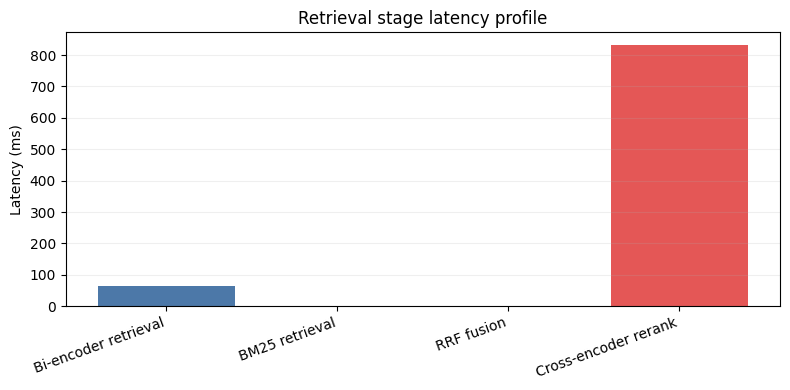

Bi-encoder retrieval    :   65.147 ms
BM25 retrieval          :    0.656 ms
RRF fusion              :    0.411 ms
Cross-encoder rerank    :  830.995 ms
Total retrieval+rerank: 897.209 ms


In [20]:
start = time.perf_counter()
q_vec = EMBED_MODEL.encode([query], normalize_embeddings=True)
D_tmp, I_tmp = faiss_index.search(np.asarray(q_vec, dtype='float32'), 20)
bi_ms = (time.perf_counter() - start) * 1000

start = time.perf_counter()
_ = bm25.get_scores(tokenize(query))
bm_ms = (time.perf_counter() - start) * 1000

start = time.perf_counter()
_ = reciprocal_rank_fusion([
    [corpus_ids[i] for i in I_tmp[0][:20]],
    [corpus_ids[i] for i in np.argsort(bm25_scores)[::-1][:20]],
], k=60)
rrf_stage_ms = (time.perf_counter() - start) * 1000

stage_latency_ms = {
    'Bi-encoder retrieval': bi_ms,
    'BM25 retrieval': bm_ms,
    'RRF fusion': rrf_stage_ms,
    'Cross-encoder rerank': rerank_ms,
}

fig, ax = plt.subplots(figsize=(8, 4))
names = list(stage_latency_ms.keys())
vals = list(stage_latency_ms.values())
ax.bar(names, vals, color=['#4c78a8', '#f58518', '#54a24b', '#e45756'])
ax.set_ylabel('Latency (ms)')
ax.set_title('Retrieval stage latency profile')
ax.set_xticklabels(names, rotation=20, ha='right')
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

for k, v in stage_latency_ms.items():
    print(f'{k:24s}: {v:8.3f} ms')
print(f'Total retrieval+rerank: {sum(vals):.3f} ms')

## Section 7: Context Assembly And LLM Prompt

### How Context Is Built

In [21]:
from app.services.rag import ContextItem, ContextBundle, rag_service

selected = reranked[:5]
context_items = []
for idx, (doc_id, txt, score) in enumerate(selected):
    context_items.append(
        ContextItem(
            citation_id='',
            chunk_id=doc_id,
            document_id=doc_id,
            document_name=f'synthetic_{doc_id}.txt',
            chunk_index=idx,
            chunk_text=txt,
            retrieval_score=float(score),
        )
    )

rag_service._assign_citation_ids(context_items, prefix='SRC')
context_text, used_items = rag_service._build_context_text(context_items)

bundle = ContextBundle(
    mode='retrieval',
    query=query,
    expanded_queries=[],
    items=used_items,
    context_text=context_text,
    reasoning_steps=[],
    retrieval_method='hybrid',
    total_candidates=20,
    retrieval_latency_ms=sum(stage_latency_ms.values()),
    context_policy=rag_service._context_policy(top_k=5),
)

print('Constructed context:')
print('-' * 80)
print(context_text[:1800])
print('-' * 80)
print('Context word count:', len(context_text.split()))

Constructed context:
--------------------------------------------------------------------------------
[SRC1] Source=synthetic_chunk_059.txt | ChunkID=chunk_059 | Page=n/a
Chunk 059: Patient with heart failure. Current therapy includes atorvastatin. Clinical focus: renal dysfunction. Consider comorbidity-aware management.

---

[SRC2] Source=synthetic_chunk_051.txt | ChunkID=chunk_051 | Page=n/a
Chunk 051: Patient with heart failure. Current therapy includes furosemide. Clinical focus: renal dysfunction. Consider comorbidity-aware management.

---

[SRC3] Source=synthetic_chunk_056.txt | ChunkID=chunk_056 | Page=n/a
Chunk 056: Patient with heart failure. Current therapy includes apixaban. Clinical focus: renal dysfunction. Consider comorbidity-aware management.

---

[SRC4] Source=synthetic_chunk_060.txt | ChunkID=chunk_060 | Page=n/a
Chunk 060: Patient with heart failure. Current therapy includes furosemide. Clinical focus: renal dysfunction. Consider comorbidity-aware management.

---

### Prompt Structure

In [22]:
from app.services.llm import llm_service

user_question = 'What is the safest antihypertensive strategy in this renal-risk scenario?'
system_prompt = rag_service.build_chat_system_prompt(bundle)
full_prompt = f"{system_prompt}\n\nContext:\n{bundle.context_text}\n\nUser question: {user_question}"

token_est = llm_service.estimate_text_tokens(full_prompt)
print('Estimated tokens (system + context + question):', token_est)

long_items = context_items * 8
rag_service._assign_citation_ids(long_items, prefix='SRC')
truncated_context, truncated_items = rag_service._build_context_text(long_items)
print('Original repeated items:', len(long_items))
print('Used after policy:', len(truncated_items))
print('Truncated context words:', len(truncated_context.split()))

Estimated tokens (system + context + question): 300
Original repeated items: 40
Used after policy: 5
Truncated context words: 119


### End-To-End Timing

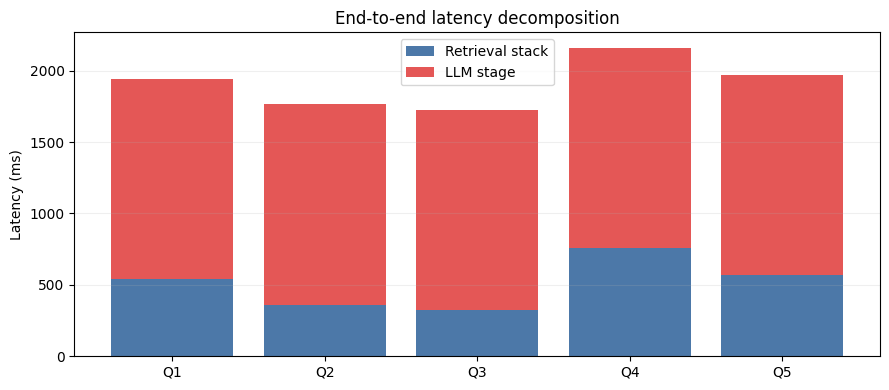

End-to-end benchmark runtime: 9563.95 ms
Q1: total=1942.84 ms | retrieval=541.64 ms | llm=1401.19 ms | mode=simulated
Q2: total=1766.70 ms | retrieval=362.46 ms | llm=1404.23 ms | mode=simulated
Q3: total=1726.23 ms | retrieval=324.80 ms | llm=1401.43 ms | mode=simulated
Q4: total=2160.09 ms | retrieval=756.87 ms | llm=1403.21 ms | mode=simulated
Q5: total=1967.40 ms | retrieval=565.94 ms | llm=1401.47 ms | mode=simulated
Bottleneck identified: LLM call


In [23]:
def run_pipeline_once(q: str):
    timings = {}

    start = time.perf_counter()
    qv = EMBED_MODEL.encode([q], normalize_embeddings=True)
    D_loc, I_loc = faiss_index.search(np.asarray(qv, dtype='float32'), 20)
    timings['faiss_ms'] = (time.perf_counter() - start) * 1000

    start = time.perf_counter()
    bm_scores = bm25.get_scores(tokenize(q))
    bm_ranked = [corpus_ids[i] for i in np.argsort(bm_scores)[::-1][:20]]
    dense_ranked = [corpus_ids[i] for i in I_loc[0][:20]]
    timings['bm25_ms'] = (time.perf_counter() - start) * 1000

    start = time.perf_counter()
    fused = reciprocal_rank_fusion([dense_ranked, bm_ranked], k=60)
    top20 = [doc for doc, _ in list(fused.items())[:20]]
    timings['rrf_ms'] = (time.perf_counter() - start) * 1000

    start = time.perf_counter()
    top20_texts = [corpus_chunks[corpus_ids.index(doc)] for doc in top20]
    _ = CROSS_ENCODER.predict([(q, txt) for txt in top20_texts])
    timings['rerank_ms'] = (time.perf_counter() - start) * 1000

    has_key = bool(os.getenv('GROQ_API_KEY')) or bool(os.getenv('GOOGLE_API_KEY'))
    start = time.perf_counter()
    if has_key and os.getenv('RUN_REAL_LLM', '0') == '1':
        from app.services.llm import llm_service as _llm
        try:
            _ = __import__('asyncio').run(
                _llm.generate(user_message=q, context=' '.join(top20_texts[:2]), temperature=0.0, max_tokens=80)
            )
            timings['llm_mode'] = 'real'
        except Exception:
            time.sleep(1.4)
            timings['llm_mode'] = 'simulated_fallback'
    else:
        time.sleep(1.4)
        timings['llm_mode'] = 'simulated'
    timings['llm_ms'] = (time.perf_counter() - start) * 1000

    timings['total_ms'] = sum(timings[k] for k in ['faiss_ms', 'bm25_ms', 'rrf_ms', 'rerank_ms', 'llm_ms'])
    return timings

queries = [
    'ACE inhibitor dose adjustment for CKD stage 3',
    'When should metformin be held around contrast imaging?',
    'Risk factors for hyperkalemia with ACE inhibitor therapy',
    'How to monitor warfarin during antibiotic treatment?',
    'Differential for dyspnea with elevated BNP',
]

start = time.perf_counter()
timing_runs = [run_pipeline_once(q) for q in queries]
bench_ms = (time.perf_counter() - start) * 1000

retrieval_totals = [r['faiss_ms'] + r['bm25_ms'] + r['rrf_ms'] + r['rerank_ms'] for r in timing_runs]
llm_totals = [r['llm_ms'] for r in timing_runs]
totals = [r['total_ms'] for r in timing_runs]

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(queries))
ax.bar(x, retrieval_totals, label='Retrieval stack', color='#4c78a8')
ax.bar(x, llm_totals, bottom=retrieval_totals, label='LLM stage', color='#e45756')
ax.set_xticks(x)
ax.set_xticklabels([f'Q{i+1}' for i in range(len(queries))])
ax.set_ylabel('Latency (ms)')
ax.set_title('End-to-end latency decomposition')
ax.legend()
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

print(f'End-to-end benchmark runtime: {bench_ms:.2f} ms')
for i, run in enumerate(timing_runs, start=1):
    print(f"Q{i}: total={run['total_ms']:.2f} ms | retrieval={retrieval_totals[i-1]:.2f} ms | llm={run['llm_ms']:.2f} ms | mode={run['llm_mode']}")

avg_total_ms = float(np.mean(totals))
avg_retrieval_ms = float(np.mean(retrieval_totals))
avg_llm_ms = float(np.mean(llm_totals))
print('Bottleneck identified:', 'LLM call' if avg_llm_ms > avg_retrieval_ms else 'retrieval stack')

## Section 8: Failure Cases

### When RAG Fails

In [24]:
failure_cases = [
    {
        'query': 'What is the recommended chemotherapy protocol for pediatric AML?',
        'expected_keywords': ['cytarabine', 'anthracycline'],
        'reason': 'Out-of-corpus domain gap',
    },
    {
        'query': 'Interpret MI in this note without extra context',
        'expected_keywords': ['myocardial infarction'],
        'reason': 'Ambiguous abbreviation',
    },
    {
        'query': 'Integrate cardiology, nephrology, endocrinology, and pulmonology plans into one timeline with contradictions resolved',
        'expected_keywords': ['timeline', 'contradiction'],
        'reason': 'Over-complex query intent',
    },
]

def keyword_hit_rate(query_text, expected_keywords, top_k=5):
    qv = EMBED_MODEL.encode([query_text], normalize_embeddings=True)
    d, i = faiss_index.search(np.asarray(qv, dtype='float32'), top_k)
    dense_hits = ' '.join(corpus_chunks[j].lower() for j in i[0])

    sparse_scores = bm25.get_scores(tokenize(query_text))
    sparse_idx = np.argsort(sparse_scores)[::-1][:top_k]
    sparse_hits = ' '.join(corpus_chunks[j].lower() for j in sparse_idx)

    fused = reciprocal_rank_fusion([
        [corpus_ids[j] for j in i[0]],
        [corpus_ids[j] for j in sparse_idx],
    ], k=60)
    fused_idx = [corpus_ids.index(doc) for doc in list(fused.keys())[:top_k]]
    fused_hits = ' '.join(corpus_chunks[j].lower() for j in fused_idx)

    dense_rate = sum(1 for kw in expected_keywords if kw.lower() in dense_hits) / len(expected_keywords)
    sparse_rate = sum(1 for kw in expected_keywords if kw.lower() in sparse_hits) / len(expected_keywords)
    fused_rate = sum(1 for kw in expected_keywords if kw.lower() in fused_hits) / len(expected_keywords)
    return dense_rate, sparse_rate, fused_rate

print('Failure-case retrieval hit rates:')
for case in failure_cases:
    d, s, h = keyword_hit_rate(case['query'], case['expected_keywords'])
    print(f"- {case['reason']}: dense={d:.2f}, bm25={s:.2f}, hybrid={h:.2f}")

Failure-case retrieval hit rates:
- Out-of-corpus domain gap: dense=0.00, bm25=0.00, hybrid=0.00


- Ambiguous abbreviation: dense=0.00, bm25=0.00, hybrid=0.00
- Over-complex query intent: dense=0.00, bm25=0.00, hybrid=0.00


### When RAG Helps Most

In [25]:
success_cases = [
    {
        'query': 'What should we monitor when using lisinopril in CKD?',
        'expected_keywords': ['lisinopril', 'renal'],
        'reason': 'Specific drug dosage/monitoring detail',
    },
    {
        'query': 'Which patient chunks mention diabetes and metformin together?',
        'expected_keywords': ['metformin', 'diabetes'],
        'reason': 'Patient-specific information lookup',
    },
    {
        'query': 'Find guidance-like text for follow-up and dose adjustment',
        'expected_keywords': ['follow-up', 'dose adjustment'],
        'reason': 'Recommendation retrieval',
    },
]

print('High-value RAG cases (hit rates):')
for case in success_cases:
    d, s, h = keyword_hit_rate(case['query'], case['expected_keywords'])
    print(f"- {case['reason']}: dense={d:.2f}, bm25={s:.2f}, hybrid={h:.2f}")

High-value RAG cases (hit rates):


- Specific drug dosage/monitoring detail: dense=1.00, bm25=0.50, hybrid=1.00
- Patient-specific information lookup: dense=1.00, bm25=1.00, hybrid=1.00


- Recommendation retrieval: dense=1.00, bm25=0.50, hybrid=0.50


## Section 9: Summary

### Key Takeaways

- Sentence-aware overlapping chunking preserves coherence better than fixed-character slicing.
- Dense retrieval captures semantic similarity; BM25 captures exact lexical anchors.
- RRF avoids score-scale mismatch and fuses rankings with negligible runtime cost.
- Cross-encoder reranking improves precision on a short list but adds noticeable latency.
- In practice, LLM generation usually dominates latency relative to retrieval stages.

### Numbers Summary

In [26]:
chunk_count = len(chunk_texts)
embed_dim = int(chunk_embeddings.shape[1])

faiss_stage = float(stage_latency_ms['Bi-encoder retrieval'])
bm25_stage = float(stage_latency_ms['BM25 retrieval'])
rrf_stage = float(stage_latency_ms['RRF fusion'])
rerank_stage = float(stage_latency_ms['Cross-encoder rerank'])
retrieval_total = faiss_stage + bm25_stage + rrf_stage + rerank_stage

print(f"""
Pipeline Summary:
  Chunking:        {chunk_count} chunks from 1 document
  Embedding dim:   {embed_dim}
  FAISS retrieval: ~{faiss_stage:.2f} ms for top-20
  BM25 retrieval:  ~{bm25_stage:.2f} ms for top-20
  RRF fusion:      ~{rrf_stage:.4f} ms
  Reranking:       ~{rerank_stage:.2f} ms for top-20->top-5
  Total retrieval: ~{retrieval_total:.2f} ms
  LLM generation:  ~{avg_llm_ms:.2f} ms ({timing_runs[0]['llm_mode']} in this run)
""")


Pipeline Summary:
  Chunking:        4 chunks from 1 document
  Embedding dim:   768
  FAISS retrieval: ~65.15 ms for top-20
  BM25 retrieval:  ~0.66 ms for top-20
  RRF fusion:      ~0.4115 ms
  Reranking:       ~830.99 ms for top-20->top-5
  Total retrieval: ~897.21 ms
  LLM generation:  ~1402.31 ms (simulated in this run)

